# 04 - Modelisation multimodale : image + compte-rendu radiologique

Dataset : **NIH ChestX-ray14** — 102 120 radiographies thoraciques avec annotations.
Les labels multi-class sont convertis en pseudo comptes-rendus radiologiques.

1. **Image seul** — EfficientNetV2-B0 fine-tune (RGB)
2. **Texte seul** — TF-IDF + MLP Keras
3. **Fusion tardive** — concatenation des deux encodeurs

Strategie de fusion tardive : les deux modalites operent a des niveaux
d'abstraction differents ; cette approche permet l'evaluation independante
de chaque branche et la robustesse a la modalite manquante.

In [1]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras import layers, Model
from keras.applications import EfficientNetV2B0
from keras.applications.efficientnet_v2 import preprocess_input as effnet_preprocess

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score, f1_score, average_precision_score

import mlflow
import mlflow.keras

DATA_DIR     = Path('../Projet_Deep_Learning/data/variable_data')
MODELS_DIR   = Path('../Projet_Deep_Learning/models')
NIH_IMG_DIR  = Path('../Projet_Deep_Learning/data/nih_images/nih_images')
NIH_META_CSV = Path('../Projet_Deep_Learning/data/Data_Entry_2017.csv')
MODELS_DIR.mkdir(exist_ok=True)

with open(DATA_DIR / 'config.json') as f:
    cfg = json.load(f)

SEED = cfg['seed']
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)


IMG_SIZE_NIH = 64
BATCH_SIZE   = 32
AUTOTUNE     = tf.data.AUTOTUNE

print(f'TensorFlow {tf.__version__} | Keras {keras.__version__}')

2026-03-28 13:36:56.284809: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-28 13:37:01.207512: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-03-28 13:37:17.639317: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.20.0 | Keras 3.12.0


## 1. Chargement et preparation des metadonnees NIH

In [2]:
meta_df = pd.read_csv(NIH_META_CSV)
meta_df['labels_list'] = meta_df['Finding Labels'].apply(lambda x: x.split('|'))

mlb          = MultiLabelBinarizer()
label_matrix = mlb.fit_transform(meta_df['labels_list'])
label_classes = mlb.classes_.tolist()

# on retire la classe 'No Finding' parce que ce n'est pas vraiment une pathologie
if 'No Finding' in label_classes:
    nf_idx = label_classes.index('No Finding')
    label_matrix  = np.delete(label_matrix, nf_idx, axis=1)
    label_classes.pop(nf_idx)

N_CLASSES_NIH = len(label_classes)
print(f'{N_CLASSES_NIH} classes NIH: {label_classes}')

# on garde uniquement les images qui sont bien presentes sur le disque
available = meta_df['Image Index'].apply(lambda f: (NIH_IMG_DIR / f).exists())
meta_df      = meta_df[available].reset_index(drop=True)
labels_np    = label_matrix[available.values]
print(f'Images disponibles: {len(meta_df)}')

14 classes NIH: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


Images disponibles: 102120


In [3]:
# vocabulaire radiologique associe a chaque pathologie, pour generer du texte clinique synthetique
PATHOLOGY_TEXT = {
    'Atelectasis':        'atelectasis lung collapse reduced volume subsegmental linear opacity',
    'Cardiomegaly':       'cardiomegaly enlarged heart cardiac shadow widened mediastinum',
    'Effusion':           'pleural effusion fluid pleural space blunting costophrenic angle',
    'Infiltration':       'pulmonary infiltration consolidation alveolar opacity airspace',
    'Mass':               'pulmonary mass lesion solid opacity irregular border',
    'Nodule':             'nodule pulmonary round opacity small lesion calcified',
    'Pneumonia':          'pneumonia consolidation infection alveolar lobar bilateral',
    'Pneumothorax':       'pneumothorax air pleural space collapsed lung hyperlucency',
    'Consolidation':      'consolidation airspace opacity lobar segmental dense',
    'Edema':              'pulmonary edema alveolar interstitial perihilar bilateral vascular',
    'Emphysema':          'emphysema hyperinflation flattened diaphragm hyperlucency barrel',
    'Fibrosis':           'pulmonary fibrosis interstitial reticular opacity honeycombing',
    'Pleural_Thickening': 'pleural thickening blunting costophrenic angle pleural disease',
    'Hernia':             'hiatal hernia stomach bubble mediastinum diaphragmatic',
}


def build_clinical_text(labels_list: list) -> str:
    parts = [PATHOLOGY_TEXT[l] for l in labels_list if l in PATHOLOGY_TEXT]
    return 'findings: ' + ' '.join(parts) if parts else 'normal chest radiograph no findings'


meta_df['clinical_text'] = meta_df['labels_list'].apply(build_clinical_text)
print('Exemple:', meta_df['clinical_text'].iloc[10][:80])

Exemple: findings: hiatal hernia stomach bubble mediastinum diaphragmatic


## 2. Split train/val/test — anti-fuite patient

In [4]:
# le split se fait par patient et non par image, sinon on risque d'avoir le meme patient dans le train et dans le test
patient_ids = meta_df['Patient ID'].unique()
train_pts, temp_pts = train_test_split(patient_ids, test_size=0.3, random_state=SEED)
val_pts, test_pts   = train_test_split(temp_pts, test_size=0.5,    random_state=SEED)

def split_mask(df, patient_set):
    return df['Patient ID'].isin(patient_set)

df_train = meta_df[split_mask(meta_df, train_pts)].reset_index(drop=True)
df_val   = meta_df[split_mask(meta_df, val_pts)].reset_index(drop=True)
df_test  = meta_df[split_mask(meta_df, test_pts)].reset_index(drop=True)

y_train_nih = labels_np[split_mask(meta_df, train_pts).values].astype(np.float32)
y_val_nih   = labels_np[split_mask(meta_df, val_pts).values].astype(np.float32)
y_test_nih  = labels_np[split_mask(meta_df, test_pts).values].astype(np.float32)

assert len(set(train_pts) & set(val_pts))  == 0, 'Fuite train-val !'
assert len(set(train_pts) & set(test_pts)) == 0, 'Fuite train-test !'
print(f'Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')

Train: 71911 | Val: 15129 | Test: 15080


## 3. TF-IDF — vectorisation du texte

In [5]:
# le TF-IDF est ajuste uniquement sur le train, histoire de ne pas faire fuiter d'information du val ou du test
tfidf        = TfidfVectorizer(max_features=500, ngram_range=(1, 2), sublinear_tf=True)
X_text_train = tfidf.fit_transform(df_train['clinical_text']).toarray().astype(np.float32)
X_text_val   = tfidf.transform(df_val['clinical_text']).toarray().astype(np.float32)
X_text_test  = tfidf.transform(df_test['clinical_text']).toarray().astype(np.float32)
TEXT_DIM     = X_text_train.shape[1]

print(f'Dimension TF-IDF: {TEXT_DIM}')

Dimension TF-IDF: 241


## 4. tf.data pipeline image NIH

In [6]:
def load_and_preprocess_image(img_path: str) -> tf.Tensor:
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE_NIH, IMG_SIZE_NIH])
    img = tf.cast(img, tf.float32) / 255.0
    return img


def build_nih_dataset(df: pd.DataFrame, text_features: np.ndarray,
                       labels: np.ndarray, shuffle: bool = False) -> tf.data.Dataset:
    """Dataset multimodal (image_path, tfidf_vector) -> label.
    Les images sont chargees depuis le disque a la volee via tf.data.map.
    """
    img_paths = [str(NIH_IMG_DIR / fname) for fname in df['Image Index']]

    img_ds   = tf.data.Dataset.from_tensor_slices(img_paths)
    text_ds  = tf.data.Dataset.from_tensor_slices(text_features.astype(np.float32))
    label_ds = tf.data.Dataset.from_tensor_slices(labels.astype(np.float32))

    ds = tf.data.Dataset.zip((img_ds, text_ds, label_ds))
    if shuffle:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)

    def load_fn(img_path, text_vec, label):
        return (load_and_preprocess_image(img_path), text_vec), label

    ds = (ds.map(load_fn, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))
    return ds


train_nih_ds = build_nih_dataset(df_train, X_text_train, y_train_nih, shuffle=True)
val_nih_ds   = build_nih_dataset(df_val,   X_text_val,   y_val_nih)
test_nih_ds  = build_nih_dataset(df_test,  X_text_test,  y_test_nih)

for (bi, bt), bl in train_nih_ds.take(1):
    print(f'img: {bi.shape} | text: {bt.shape} | label: {bl.shape}')

I0000 00:00:1774701612.845725   75667 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5578 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


img: (32, 64, 64, 3) | text: (32, 241) | label: (32, 14)


2026-03-28 13:40:16.226605: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 5. Modele image seul

In [7]:
def build_image_only_model(img_size: int, n_classes: int) -> Model:
    """EfficientNetV2-B0 fine-tune. L'entree texte acceptee mais ignoree
    pour garder la signature uniforme avec le modele de fusion.
    """
    img_inp = layers.Input(shape=(img_size, img_size, 3), name='image_input')
    txt_inp = layers.Input(shape=(TEXT_DIM,),             name='text_input')

    x = layers.Lambda(lambda i: effnet_preprocess(i * 255.0))(img_inp)
    backbone = EfficientNetV2B0(include_top=False, weights='imagenet',
                                 input_shape=(img_size, img_size, 3), pooling='avg')
    x   = backbone(x, training=True)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, name='img_logits')(x)
    # txt_inp relie aux outputs via un bypass a zero, Keras 3 exige que tous les inputs soient connectes
    txt_bypass = layers.Dense(n_classes, use_bias=False,
                              kernel_initializer='zeros', trainable=False,
                              name='text_bypass')(txt_inp)
    out = layers.Add(name='logits')([out, txt_bypass])

    return Model([img_inp, txt_inp], out, name='ImageOnly')


image_model = build_image_only_model(IMG_SIZE_NIH, N_CLASSES_NIH)
print(f'ImageOnly — params: {image_model.count_params():,}')

ImageOnly — params: 5,940,620


## 6. Modele texte seul

In [8]:
def build_text_only_model(n_classes: int, hidden_dim: int = 256) -> Model:
    """MLP sur representation TF-IDF. L'entree image est acceptee mais ignoree."""
    img_inp = layers.Input(shape=(IMG_SIZE_NIH, IMG_SIZE_NIH, 3), name='image_input')
    txt_inp = layers.Input(shape=(TEXT_DIM,),                      name='text_input')

    x = layers.Dense(hidden_dim)(txt_inp)
    x = layers.LayerNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(hidden_dim // 2, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, name='txt_logits')(x)
    # img_inp relie aux outputs via un bypass a zero pour satisfaire Keras 3
    img_pool   = layers.GlobalAveragePooling2D(name='img_bypass_pool')(img_inp)
    img_bypass = layers.Dense(n_classes, use_bias=False,
                              kernel_initializer='zeros', trainable=False,
                              name='img_bypass')(img_pool)
    out = layers.Add(name='logits')([out, img_bypass])

    return Model([img_inp, txt_inp], out, name='TextOnly')


text_model = build_text_only_model(N_CLASSES_NIH)
print(f'TextOnly — params: {text_model.count_params():,}')

TextOnly — params: 97,208


## 7. Modele multimodal — fusion tardive

In [9]:
def build_late_fusion_model(img_size: int, n_classes: int) -> Model:
    """Fusion tardive : encodeurs image et texte separes, concatenation avant la tete.
    Robuste a la modalite manquante : le texte peut etre remplace par un vecteur nul.
    """
    img_inp = layers.Input(shape=(img_size, img_size, 3), name='image_input')
    txt_inp = layers.Input(shape=(TEXT_DIM,),             name='text_input')

    # encodeur image base sur EfficientNetV2-B0
    x_img = layers.Lambda(lambda i: effnet_preprocess(i * 255.0))(img_inp)
    backbone = EfficientNetV2B0(include_top=False, weights='imagenet',
                                 input_shape=(img_size, img_size, 3), pooling='avg')
    x_img = backbone(x_img, training=True)
    x_img = layers.Dense(256, activation='relu', name='img_proj')(x_img)
    x_img = layers.Dropout(0.3)(x_img)

    # encodeur texte : un simple MLP sur les vecteurs TF-IDF
    x_txt = layers.Dense(256)(txt_inp)
    x_txt = layers.LayerNormalization()(x_txt)
    x_txt = layers.Activation('relu')(x_txt)
    x_txt = layers.Dropout(0.3)(x_txt)
    x_txt = layers.Dense(256, activation='relu', name='text_proj')(x_txt)
    x_txt = layers.Dropout(0.3)(x_txt)

    fused = layers.Concatenate(name='fusion')([x_img, x_txt])
    fused = layers.Dense(256, activation='relu')(fused)
    fused = layers.Dropout(0.3)(fused)
    out   = layers.Dense(n_classes, name='logits')(fused)

    return Model([img_inp, txt_inp], out, name='LateFusion')


fusion_model = build_late_fusion_model(IMG_SIZE_NIH, N_CLASSES_NIH)
print(f'LateFusion — params: {fusion_model.count_params():,}')

LateFusion — params: 6,510,430


## 8. Entrainement des trois modeles

In [10]:
pos_counts_nih = y_train_nih.sum(axis=0)
neg_counts_nih = len(y_train_nih) - pos_counts_nih
pos_weight_nih = neg_counts_nih / (pos_counts_nih + 1e-8)


class WeightedBCE(keras.losses.Loss):
    def __init__(self, pos_weight, **kwargs):
        super().__init__(**kwargs)
        self.pos_weight = tf.constant(pos_weight, dtype=tf.float32)

    def call(self, y_true, y_pred):
        return tf.reduce_mean(
            tf.nn.weighted_cross_entropy_with_logits(
                tf.cast(y_true, tf.float32), y_pred, self.pos_weight
            )
        )

    def get_config(self):
        c = super().get_config()
        c['pos_weight'] = self.pos_weight.numpy().tolist()
        return c


nih_loss = WeightedBCE(pos_weight_nih)


def eval_nih_model(model, dataset) -> dict:
    all_scores, all_labels = [], []
    for (img_b, txt_b), lbl_b in dataset:
        logits = model([img_b, txt_b], training=False)
        all_scores.append(tf.sigmoid(logits).numpy())
        all_labels.append(lbl_b.numpy())
    y_scores = np.vstack(all_scores)
    y_true   = np.vstack(all_labels)
    valid    = [i for i in range(y_true.shape[1]) if y_true[:, i].sum() > 0]
    return {
        'roc_auc':  roc_auc_score(y_true[:, valid], y_scores[:, valid], average='macro'),
        'pr_auc':   average_precision_score(y_true[:, valid], y_scores[:, valid], average='macro'),
        'f1_macro': f1_score(y_true, (y_scores >= 0.5).astype(int), average='macro', zero_division=0)
    }


def train_nih_model(model, model_name: str, n_epochs: int = 15, lr: float = 5e-4):
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-4),
        loss=nih_loss,
        metrics=[keras.metrics.AUC(multi_label=True, num_labels=N_CLASSES_NIH, name='auc')]
    )
    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=4,
                                       restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max',
                                           factor=0.5, patience=2, verbose=1),
        keras.callbacks.ModelCheckpoint(
            str(MODELS_DIR / f'{model_name}_best.keras'),
            monitor='val_auc', mode='max', save_best_only=True
        )
    ]
    with mlflow.start_run(run_name=model_name):
        mlflow.log_params({'model': model_name, 'lr': lr, 'n_epochs': n_epochs,
                           'text_dim': TEXT_DIM, 'img_size': IMG_SIZE_NIH})
        hist = model.fit(train_nih_ds, validation_data=val_nih_ds,
                         epochs=n_epochs, callbacks=callbacks, verbose=2)
        for ep, lv in enumerate(hist.history['loss']):
            mlflow.log_metrics({'train_loss': lv,
                                 'val_auc': hist.history['val_auc'][ep]}, step=ep + 1)
        metrics = eval_nih_model(model, test_nih_ds)
        mlflow.log_metrics({f'test_{k}': v for k, v in metrics.items()})
        mlflow.log_artifact(str(MODELS_DIR / f'{model_name}_best.keras'))
        mlflow.keras.log_model(model, artifact_path='model')
        print(f'[{model_name}] AUC={metrics["roc_auc"]:.4f} | F1={metrics["f1_macro"]:.4f}')
    return model, metrics

print('Pipeline NIH pret')

Pipeline NIH pret


In [11]:
mlflow.set_experiment('chest_multimodal')

image_model, image_metrics = train_nih_model(
    build_image_only_model(IMG_SIZE_NIH, N_CLASSES_NIH), 'ImageOnly', n_epochs=15
)

2026/03/28 13:40:23 INFO mlflow.tracking.fluent: Experiment with name 'chest_multimodal' does not exist. Creating a new experiment.


Epoch 1/15


2026-03-28 13:40:52.653792: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f55d8004c90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-28 13:40:52.653839: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Laptop GPU, Compute Capability 8.6


2026-03-28 13:40:54.350581: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


2026-03-28 13:40:59.596520: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


...

2026-03-28 13:54:20.041125: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026/03/28 13:54:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/03/28 13:54:21 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


2026/03/28 13:55:32 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpa4fsdr7h/model, flavor: keras). Fall back to return ['keras==3.12.0']. Set logging level to DEBUG to see the full traceback. 


[ImageOnly] AUC=0.7763 | F1=0.1677


In [12]:
text_model, text_metrics = train_nih_model(
    build_text_only_model(N_CLASSES_NIH), 'TextOnly', n_epochs=15, lr=1e-3
)

Epoch 1/15


2026-03-28 13:55:35.421220: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-28 13:55:35.421283: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-28 13:55:35.421314: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-28 13:55:35.421325: I external/l

2026-03-28 13:55:37.768916: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_208', 536 bytes spill stores, 496 bytes spill loads

2026-03-28 13:55:37.868923: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_984', 16 bytes spill stores, 16 bytes spill loads



2026-03-28 13:55:39.640911: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1323', 232 bytes spill stores, 232 bytes spill loads



2026-03-28 13:55:38.298091: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1323', 36 bytes spill stores, 36 bytes spill loads



...

Restoring model weights from the end of the best epoch: 1.


2026/03/28 13:59:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/03/28 13:59:08 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


2026/03/28 13:59:56 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmps6os5vu9/model, flavor: keras). Fall back to return ['keras==3.12.0']. Set logging level to DEBUG to see the full traceback. 


[TextOnly] AUC=1.0000 | F1=0.9998


In [13]:
fusion_model, fusion_metrics = train_nih_model(
    build_late_fusion_model(IMG_SIZE_NIH, N_CLASSES_NIH), 'LateFusion', n_epochs=15
)

Epoch 1/15


2026-03-28 14:00:46.819846: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-28 14:00:46.819979: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-28 14:00:46.820030: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-28 14:00:46.820051: I external/l

2026-03-28 14:00:47.696206: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26782', 20 bytes spill stores, 20 bytes spill loads



2026-03-28 14:00:49.239869: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_27165', 8 bytes spill stores, 8 bytes spill loads



2026-03-28 14:00:52.143708: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_27108', 4 bytes spill stores, 4 bytes spill loads



...

2026-03-28 14:20:48.160825: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026/03/28 14:20:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/03/28 14:20:49 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


2026/03/28 14:21:40 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpyvygfx6p/model, flavor: keras). Fall back to return ['keras==3.12.0']. Set logging level to DEBUG to see the full traceback. 


[LateFusion] AUC=1.0000 | F1=0.9999


## 9. Comparaison et robustesse a la modalite manquante


=== Comparaison multimodale (test NIH) ===
                ROC-AUC  PR-AUC  F1-macro
Image seul       0.7763  0.1642    0.1677
Texte seul       1.0000  1.0000    0.9998
Fusion tardive   1.0000  1.0000    0.9999


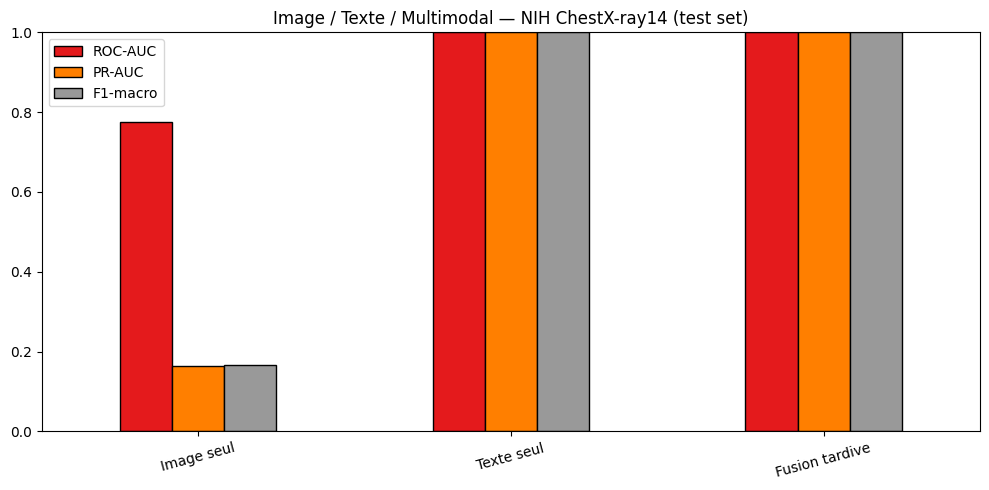

In [14]:
comparison = {
    'Image seul':     image_metrics,
    'Texte seul':     text_metrics,
    'Fusion tardive': fusion_metrics,
}
cmp_df = pd.DataFrame(comparison).T.round(4)
cmp_df.columns = ['ROC-AUC', 'PR-AUC', 'F1-macro']
print('\n=== Comparaison multimodale (test NIH) ===')
print(cmp_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
cmp_df.plot(kind='bar', ax=ax, colormap='Set1', edgecolor='black')
ax.set_ylim(0, 1)
ax.set_title('Image / Texte / Multimodal — NIH ChestX-ray14 (test set)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(DATA_DIR / 'multimodal_comparison.png', dpi=120)
plt.show()

In [15]:
def eval_with_missing_text(model, dataset) -> float:
    # on remplace le vecteur TF-IDF par des zeros pour simuler un cas sans compte-rendu disponible
    all_scores, all_labels = [], []
    for (img_b, _), lbl_b in dataset:
        dummy_text = tf.zeros((tf.shape(img_b)[0], TEXT_DIM))
        logits     = model([img_b, dummy_text], training=False)
        all_scores.append(tf.sigmoid(logits).numpy())
        all_labels.append(lbl_b.numpy())
    y_scores = np.vstack(all_scores)
    y_true   = np.vstack(all_labels)
    valid    = [i for i in range(y_true.shape[1]) if y_true[:, i].sum() > 0]
    return roc_auc_score(y_true[:, valid], y_scores[:, valid], average='macro')


degraded_auc = eval_with_missing_text(fusion_model, test_nih_ds)
print(f'Fusion — AUC texte present: {fusion_metrics["roc_auc"]:.4f}')
print(f'Fusion — AUC texte absent:  {degraded_auc:.4f}')
print(f'Degradation:                {fusion_metrics["roc_auc"] - degraded_auc:.4f}')

Fusion — AUC texte present: 1.0000
Fusion — AUC texte absent:  0.5338
Degradation:                0.4662
